## Imports

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import json
import os 
from datetime import datetime 
from pathlib import Path

## Ingestão

In [2]:
df = pd.read_csv('data/incidents_master.csv')

In [3]:
df.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,https://www.sterling-forge-markets-ho.com/news...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,https://www.sierra-quantum-innovation.com/news...,NaN,company_pr,2,79.82,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    object 
 1   company_name              850 non-null    object 
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    object 
 4   industry_primary          850 non-null    object 
 5   industry_secondary        153 non-null    object 
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    object 
 9   incident_date             850 non-null    object 
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    object 
 12  disclosure_date           850 non-null    object 
 13  attack_vector_primary     850 non-null    object 
 14  attack_vec

In [5]:
df.isna().sum()

incident_id                   0
company_name                  0
company_revenue_usd           0
country_hq                    0
industry_primary              0
industry_secondary          697
employee_count                0
is_public_company             0
stock_ticker                438
incident_date                 0
incident_date_estimated       0
discovery_date                0
disclosure_date               0
attack_vector_primary         0
attack_vector_secondary     639
attack_chain                275
attributed_group            368
attribution_confidence      368
data_compromised_records    248
data_type                   248
systems_affected              0
downtime_hours              430
data_source_primary           0
data_source_secondary       464
data_source_type              0
confidence_tier               0
quality_score                 0
quality_grade                 0
review_flag                 780
notes                       636
created_at                    0
updated_

### metadados de ingestão

In [6]:
df['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')

## Persistência

In [7]:
Path('data/bronze').mkdir(parents=True, exist_ok=True)

df.to_parquet('./data/bronze/bronze.parquet')

In [8]:
#tamanho dataset original em bits
Path('data/incidents_master.csv').stat().st_size

438941

In [9]:
#tamanho da camada bronze em bits
Path('data/bronze/bronze.parquet').stat().st_size

125230

In [10]:
df_bronze = pd.read_parquet('./data/bronze/bronze.parquet')

### Verificando nulos

In [11]:
# Contagem e percentual de nulos por coluna

percent_nulos = df_bronze.isnull().mean() * 100

print(percent_nulos.round(2))

incident_id                  0.00
company_name                 0.00
company_revenue_usd          0.00
country_hq                   0.00
industry_primary             0.00
industry_secondary          82.00
employee_count               0.00
is_public_company            0.00
stock_ticker                51.53
incident_date                0.00
incident_date_estimated      0.00
discovery_date               0.00
disclosure_date              0.00
attack_vector_primary        0.00
attack_vector_secondary     75.18
attack_chain                32.35
attributed_group            43.29
attribution_confidence      43.29
data_compromised_records    29.18
data_type                   29.18
systems_affected             0.00
downtime_hours              50.59
data_source_primary          0.00
data_source_secondary       54.59
data_source_type             0.00
confidence_tier              0.00
quality_score                0.00
quality_grade                0.00
review_flag                 91.76
notes         

<Axes: >

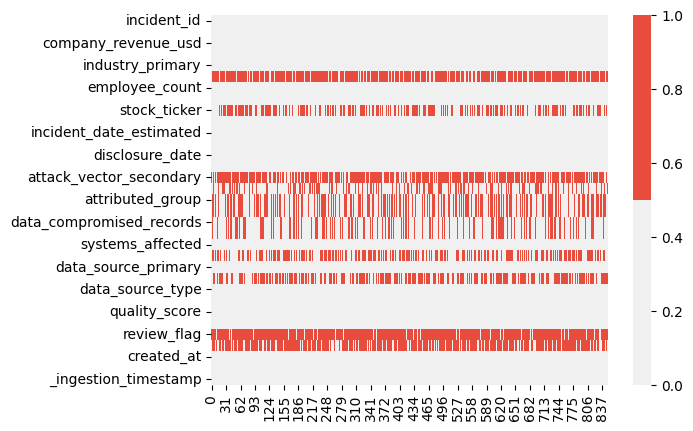

In [12]:
# Visualizacao do mapa de nulos
plt.Figure(figsize=(12,5))
sns.heatmap(df_bronze.isnull().T, cmap=['#F0F0F0','#E74C3C'])


## Buscando duplicatas

In [13]:
df_bronze[df_bronze.duplicated() == True]

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at,_ingestion_timestamp


In [14]:
df_bronze.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at,_ingestion_timestamp
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,None,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-06
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,None,250,False,None,2025-12-11,...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,None,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-06
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,None,71369,True,BITW,2023-01-15,...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,None,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-06
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,None,912,True,SFM,2021-03-15,...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,None,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-06
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,None,1662,True,SQI,2021-12-04,...,None,company_pr,2,79.82,Silver,None,None,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-06


In [15]:
df_bronze[df_bronze.duplicated(subset=['incident_id']) == True]


,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at,_ingestion_timestamp


## Conversão de tipos

In [16]:
# Datas
for col in ['incident_date', 'discovery_date', 'disclosure_date', '_ingestion_timestamp']:
    df_bronze[col] = pd.to_datetime(df_bronze[col], errors='coerce')

# created_at e updated_at têm fuso
df_bronze['created_at'] = pd.to_datetime(df_bronze['created_at'], utc=True, errors='coerce')
df_bronze['updated_at']  = pd.to_datetime(df_bronze['updated_at'],  utc=True, errors='coerce')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    object 
 1   company_name              850 non-null    object 
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    object 
 4   industry_primary          850 non-null    object 
 5   industry_secondary        153 non-null    object 
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    object 
 9   incident_date             850 non-null    object 
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    object 
 12  disclosure_date           850 non-null    object 
 13  attack_vector_primary     850 non-null    object 
 14  attack_vec

In [18]:
df_bronze.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   incident_id               850 non-null    object             
 1   company_name              850 non-null    object             
 2   company_revenue_usd       850 non-null    float64            
 3   country_hq                850 non-null    object             
 4   industry_primary          850 non-null    object             
 5   industry_secondary        153 non-null    object             
 6   employee_count            850 non-null    int64              
 7   is_public_company         850 non-null    bool               
 8   stock_ticker              412 non-null    object             
 9   incident_date             850 non-null    datetime64[ns]     
 10  incident_date_estimated   850 non-null    bool               
 11  discovery_date     

# Silver

In [19]:
df_silver = df_bronze.copy()

### Ingestão 

In [20]:
print(f"Tamanho original: {df_silver.shape}")

print("\n--- Quantidade de Nulos por Coluna ---")
print(df_silver.isnull().sum())

print(f"\nLinhas totalmente duplicadas: {df_silver.duplicated().sum()}")

Tamanho original: (850, 33)

--- Quantidade de Nulos por Coluna ---
incident_id                   0
company_name                  0
company_revenue_usd           0
country_hq                    0
industry_primary              0
industry_secondary          697
employee_count                0
is_public_company             0
stock_ticker                438
incident_date                 0
incident_date_estimated       0
discovery_date                0
disclosure_date               0
attack_vector_primary         0
attack_vector_secondary     639
attack_chain                275
attributed_group            368
attribution_confidence      368
data_compromised_records    248
data_type                   248
systems_affected              0
downtime_hours              430
data_source_primary           0
data_source_secondary       464
data_source_type              0
confidence_tier               0
quality_score                 0
quality_grade                 0
review_flag                 780
note

# Limpeza, Tratamento de Datas e Padronização

### Removendo linhas totalmente duplicadas

In [21]:
df_silver = df_silver.drop_duplicates()

### Convertendo as colunas de data de texto para datetime

In [22]:
colunas_de_data = ['incident_date', 'discovery_date', 'disclosure_date', 'created_at', 'updated_at']
for col in colunas_de_data:
    df_silver[col] = pd.to_datetime(df_silver[col], errors='coerce')

### Padronizando colunas categóricas

In [23]:
colunas_categoricas = ['attack_vector_primary', 'attack_vector_secondary', 'country_hq', 'data_type', 'attribution_confidence']
for col in colunas_categoricas:
    df_silver[col] = df_silver[col].str.lower().str.strip()

### Preenchendo valores vazios em colunas secundárias de ataque e grupo com 'desconhecido'

In [24]:
df_silver['attack_vector_secondary'] = df_silver['attack_vector_secondary'].fillna('desconhecido')
df_silver['attributed_group'] = df_silver['attributed_group'].fillna('desconhecido')
df_silver['stock_ticker'] = df_silver['stock_ticker'].fillna('nao_capital_aberto')

### Preenchendo nulos em colunas numéricas com 0 (ex: empresas que não tiveram horas de inatividade)

In [25]:
df_silver['downtime_hours'] = df_silver['downtime_hours'].fillna(0)
df_silver['data_compromised_records'] = df_silver['data_compromised_records'].fillna(0)

### Remoção de colunas com risco de Data Leakage


In [26]:
colunas_leakage = ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag']

df_silver = df_silver.drop(columns=colunas_leakage)

print(f"Colunas removidas: {colunas_leakage}")
print(f"Shape após remoção: {df_silver.shape}")

Colunas removidas: ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag']
Shape após remoção: (850, 29)


### Criação do Label para Machine Learning


In [27]:
df_silver['is_high_impact'] = (
    (df_silver['data_compromised_records'] > 100_000) |
    (df_silver['downtime_hours'] > 72)
).astype(int)

print("Distribuição do label:")
print(df_silver['is_high_impact'].value_counts())
print(f"\nProporção de alto impacto: {df_silver['is_high_impact'].mean():.2%}")

Distribuição do label:
is_high_impact
0    479
1    371
Name: count, dtype: int64

Proporção de alto impacto: 43.65%


### Salvando a Camada Silver


In [28]:
Path('data/silver').mkdir(parents=True, exist_ok=True)
df_silver.to_parquet('./data/silver/silver.parquet', index=False)

print(f"Silver salvo com sucesso!")
print(f"Shape final: {df_silver.shape}")
print(f"Tamanho do arquivo: {Path('data/silver/silver.parquet').stat().st_size} bytes")

Silver salvo com sucesso!
Shape final: (850, 30)
Tamanho do arquivo: 126938 bytes


# 

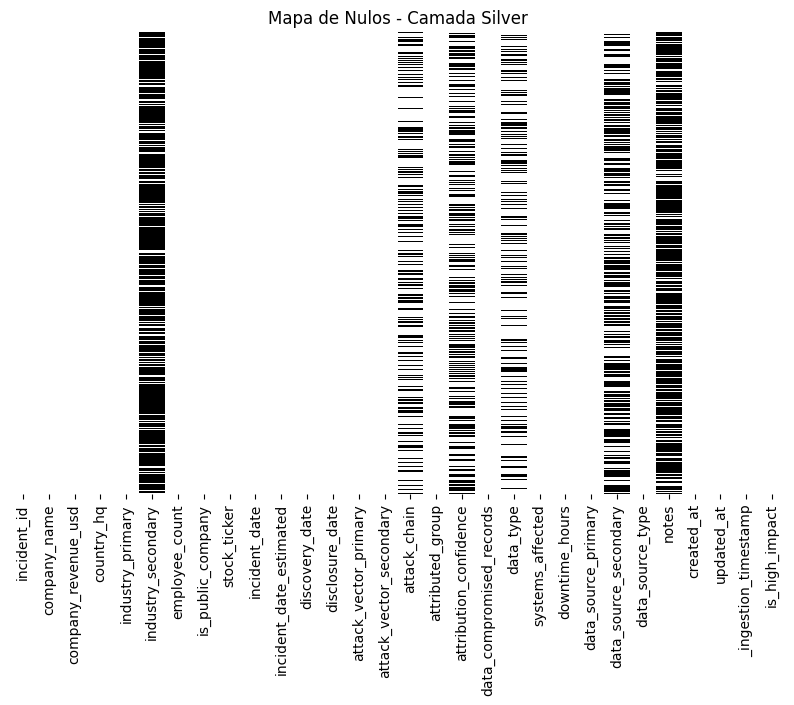

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(df_silver.isnull(), yticklabels=False, cbar=False, cmap='Greys')

plt.title('Mapa de Nulos - Camada Silver')
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_19948\2422868969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_silver, x='label_is_ransomware', palette='Set2')


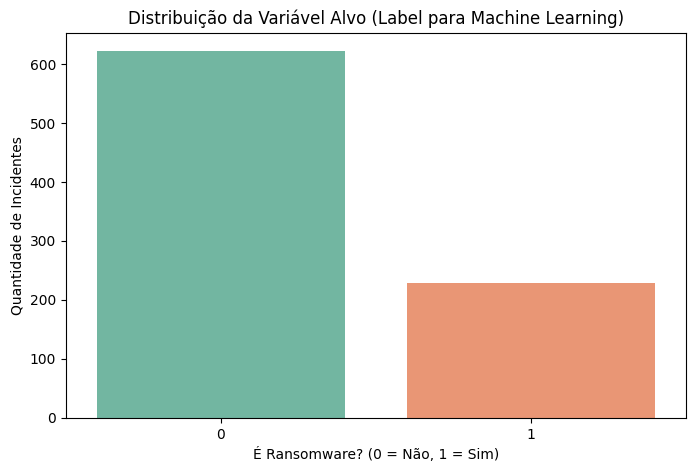

In [ ]:
plt.figure(figsize=(8, 5))

# Gráfico de barras para contar os tipos do label criadas
ax = sns.countplot(data=df_silver, x='label_is_ransomware', palette='Set2')

plt.title('Distribuição da Variável Alvo (Label para Machine Learning)')
plt.xlabel('É Ransomware? (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Incidentes')

plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_19948\1912410602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')


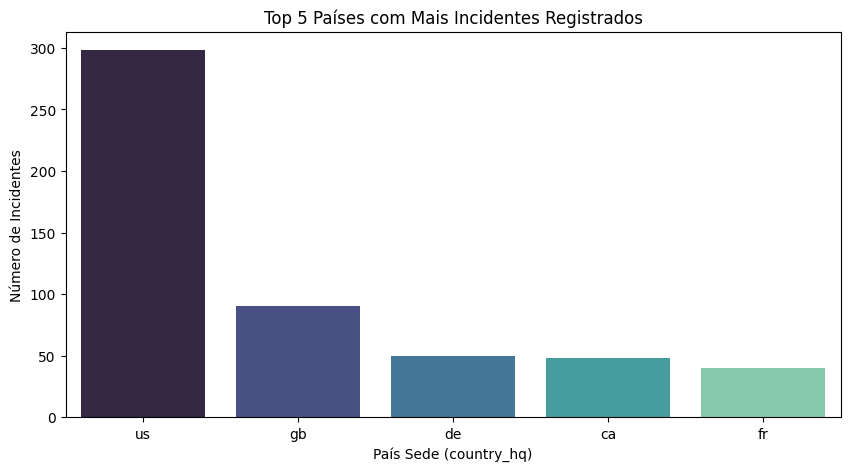

In [ ]:
plt.figure(figsize=(10, 5))

top_paises = df_silver['country_hq'].value_counts().head(5)

sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')

plt.title('Top 5 Países com Mais Incidentes Registrados')
plt.xlabel('País Sede (country_hq)')
plt.ylabel('Número de Incidentes')

plt.show()